In [1]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import requests
import matplotlib.pyplot as plt
import torch.nn as nn
import torch

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# Init SegFormer
processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes").to(device) # move to gpu if available

In [5]:
# Get input image
url = "https://plus.unsplash.com/premium_photo-1673210886161-bfcc40f54d1f?ixlib=rb-4.0.3&ixid=MnwxMjA3fDB8MHxzZWFyY2h8MXx8cGVyc29uJTIwc3RhbmRpbmd8ZW58MHx8MHx8&w=1000&q=80"

image = Image.open(requests.get(url, stream=True).raw)


inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()} # move input tensors to gpu if available

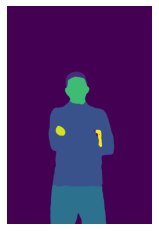

In [6]:
# Run inference
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits  # still on gpu

# Upsample to original image size
upsampled_logits = nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

# Move prediction back to cpu for display
pred_seg = upsampled_logits.argmax(dim=1)[0].cpu()

plt.imshow(pred_seg)
plt.axis("off")
plt.show()